In [5]:
#conda activate flood

import warnings
import matplotlib
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
from scipy.stats import skew
from scipy.stats import wasserstein_distance

In [80]:
ka_ranges,ka_df = pickle.load(open(f'03_ka.p','rb'))
ku_ranges,ku_df = pickle.load(open(f'03_ku.p','rb'))

pit_indices={}
pit_indices['ku']=[8,48,84,118,145,184,213]
pit_indices['ka'] = [26, 93, 164,213, 270,355,402]

day='03'

In [101]:
ka_ranges,ka_df = pickle.load(open(f'02_ka.p','rb'))
ku_ranges,ku_df = pickle.load(open(f'02_ku.p','rb'))

pit_indices={}
pit_indices['ku']=[5,37,71,94,123,161,182]
pit_indices['ka'] = [35, 113, 175, 221, 279, 354, 394]
data_dict=pickle.load(open('data_dict.p','rb'))
day='02'

In [102]:
xinterp=np.arange(-0.2,0.5,0.01)
    
skews_ice = {'ku':[],'ka':[]}
skews_snow = {'ku':[],'ka':[]}

mean_wfms = {'ku':[],'ka':[]}
median_wfms = {'ku':[],'ka':[]}

xmaxs={'ku':[],'ka':[]}

snow_surf_vals={'ku':[],'ka':[]}
wet_inter_vals={'ku':[],'ka':[]}

for i in range(0,7):

    print(i)
    
    for freq in ['ku','ka']:

        df = ka_df if freq=='ka' else ku_df
        ranges = ka_ranges if freq=='ka' else ku_ranges
        
        pit_ind=pit_indices[freq][i]


        along_track = df['along_track'].loc[pit_ind]
        arg_start = np.argmin(np.abs(df['along_track']-along_track-1))
        arg_end = np.argmin(np.abs(df['along_track']-along_track+1))

        print(pit_ind,arg_start,arg_end,arg_start-arg_end)
        
        ## y2 will be a list of aligned and oversampled waveforms
        y2=[]

        if day=='02':     (a,b)=(arg_end,arg_start)
        elif day == '03': (a,b)= (arg_start,arg_end)
            
        for j in range(df.shape[0])[a:b]:

            ind = df.index[j]

            d = df.loc[ind]
            power=d['vv']
            shift=int(d['shifts'])
            range_shift=d['range_shift']
            
            # Interpolate waveform onto xinterp
            yinterp=np.interp(xinterp,ranges-range_shift,power)
            y2.append(yinterp)
        
        y2mean=np.nanmean(y2,axis=0)
        y2median=np.nanmedian(y2,axis=0)

        mean_wfms[freq].append(y2mean)
        median_wfms[freq].append(y2median)

        ind0 = np.argmin(np.abs(xinterp))
        # Iterate through individual waveforms and 
        # extract values at snow surf
        y0s=[]
        for vals in y2:
            y0s.append(vals[ind0])

        snow_surf_vals[freq].append(  np.mean(y0s)/np.median(y0s)  )
        
        skews_snow[freq].append(skew(y0s))
            
        # chop the waveform so we can focus on the ice peak
        xchop=xinterp[xinterp>0.2]
        ychop=y2mean[xinterp>0.2]
    
        # Find index of ymax
        indmax=np.argmax(ychop)
        # Find x coordinate of y max
        xmax=xchop[indmax]
        xmaxs[freq].append(xmax)

        # Iterate through individual waveforms and extract values at indmax
        ymaxs=[]
        for vals in y2:
            ymaxs.append(vals[indmax])
    
        # Append to list of Ku-band skews where each 
        # item is the skew of the wfm at the ice surf
        skews_ice[freq].append(skew(ymaxs))

        # print(f'{freq} mean snow surf')
        # print(np.mean(ymaxs))
        # print(f'{freq} median snow surf')
        # print(np.median(ymaxs))

        wet_inter_vals[freq].append(  np.mean(ymaxs)/np.median(ymaxs)  )

0
5 13 0 13
35 32 0 32
1
37 46 32 14
113 100 69 31
2
71 78 65 13
175 167 131 36
3
94 101 87 14
221 213 183 30
4
123 130 116 14
279 266 240 26
5
161 166 152 14
354 338 297 41
6
182 191 177 14
394 379 357 22


In [103]:
np.nanmean(wet_inter_vals['ku']),np.nanmean(snow_surf_vals['ku'])

(np.float64(1.4258654010896714), np.float64(1.0793883825066772))

In [104]:
np.nanmean(wet_inter_vals['ka']),np.nanmean(snow_surf_vals['ka'])

(np.float64(1.5292708207893526), np.float64(1.2648302492724803))

In [105]:
ice_skew_ku=np.mean(skews_ice['ku'])
ice_skew_ka=np.mean(skews_ice['ka'])
snow_skew_ku=np.mean(skews_snow['ku'])
snow_skew_ka=np.mean(skews_snow['ka'])

print(ice_skew_ku,ice_skew_ka,snow_skew_ku,snow_skew_ka)

1.1861421556102705 2.058665294310077 0.398599651961087 1.4067578517986519


In [106]:
mean_wassers=[]
median_wassers=[]

for i in range(7):
    
    y2mean_ka= mean_wfms['ka'][i]
    y2median_ka= median_wfms['ka'][i]
    y2mean_ku= mean_wfms['ku'][i]
    y2median_ku= median_wfms['ku'][i]

    mean_wassers.append( wasserstein_distance(y2mean_ku,y2mean_ka) )
    median_wassers.append( wasserstein_distance(y2median_ku,y2median_ka) )



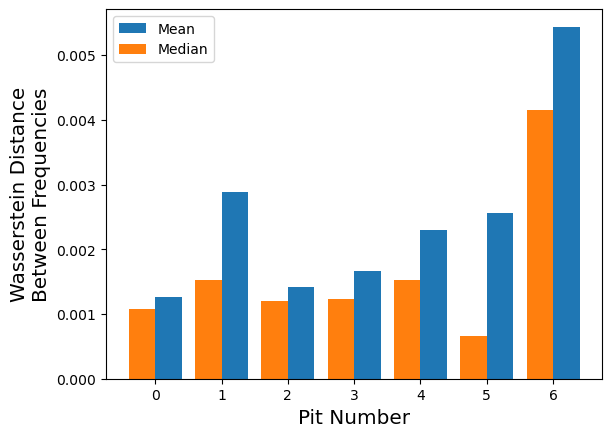

In [107]:
bw=0.4
plt.bar(np.arange(7)+0.2,mean_wassers,label='Mean',width=bw)
plt.bar(np.arange(7)-0.2,median_wassers,label='Median',width=bw)
plt.ylabel('Wasserstein Distance\nBetween Frequencies',fontsize='x-large')
plt.xlabel('Pit Number',fontsize='x-large')
plt.legend()

In [108]:
np.mean(mean_wassers),np.mean(median_wassers)

(np.float64(0.0025030292813336577), np.float64(0.0016261843745249344))

In [109]:
np.mean(mean_wassers)/np.mean(median_wassers)

np.float64(1.5392038692198604)

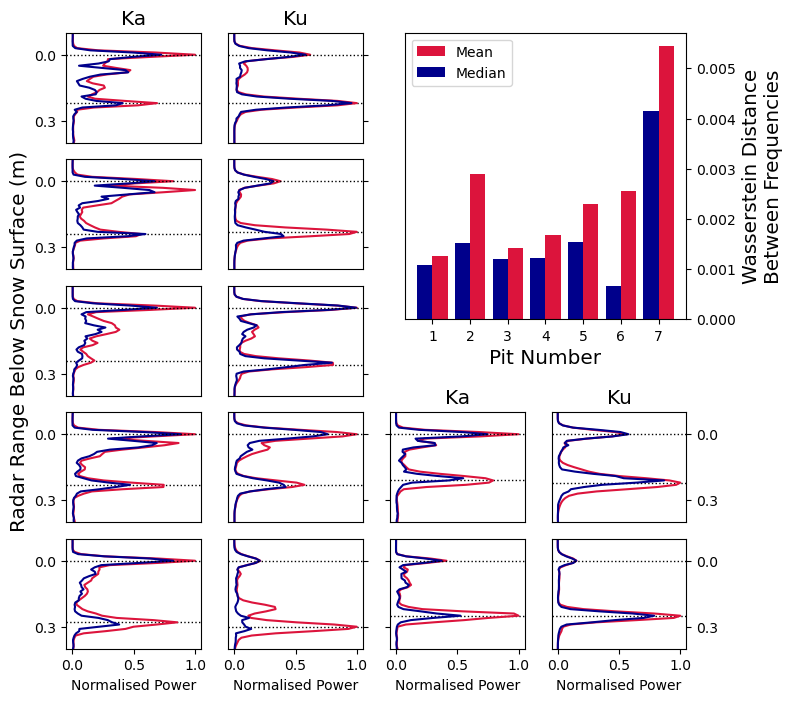

In [110]:
fig,axs=plt.subplots(5,4,figsize=(8,8))

a = list(axs.reshape(-1))

pairs = [(a[0],a[1]),(a[4],a[5]),(a[8],a[9]),(a[12],a[13]),(a[14],a[15]),(a[16],a[17]),(a[18],a[19])]

# for ax in axs[1::4]:
#     ax.set_yticklabels([])

for ax in [a[1],a[5],a[9],a[13],a[14],a[18],a[17]]:
    ax.set_yticklabels([])


for ax in [a[15],a[19]]:
    ax.yaxis.tick_right()
    

for ax in [a[2],a[3],a[6],a[7],a[10],a[11]]:
    ax.remove()

for i,(ax1,ax2) in enumerate(pairs):

    y2mean_ka= mean_wfms['ka'][i]
    y2median_ka= median_wfms['ka'][i]
    max_val=np.max(np.append(y2mean_ka,y2median_ka))


    
    y2mean_ka=y2mean_ka/max_val
    y2median_ka=y2median_ka/max_val
    
    
    y2mean_ku= mean_wfms['ku'][i]
    y2median_ku= median_wfms['ku'][i]
    max_val=np.max(np.append(y2mean_ku,y2median_ku))
    y2mean_ku=y2mean_ku/max_val
    y2median_ku=y2median_ku/max_val
    
    xmaxku=xmaxs['ku'][i]
    xmaxka=xmaxs['ka'][i]
    
    ax1.axhline(xmaxka,color='k',ls=':',lw=1)
    ax2.axhline(xmaxku,color='k',ls=':',lw=1)
    
    ax1.plot(y2mean_ka,xinterp,label='Mean',color='crimson')
    ax1.plot(y2median_ka,xinterp,label='Median',color='darkblue')
    ax1.axhline(0,color='k',ls=':',lw=1)
    # ax1.axhline(0.23,color='k',ls=':',lw=1)
    ax1.set_ylim(0.4,-0.1)
    ax1.set_yticks([0,0.3])

    ax2.plot(y2mean_ku,xinterp,label='Mean',color='crimson')
    ax2.plot(y2median_ku,xinterp,label='Median',color='darkblue')
    ax2.axhline(0,color='k',ls=':',lw=1)
    ax2.set_yticks([0,0.3])

    ax2.set_ylim(0.4,-0.1)

    ax2.yaxis.tick_right()
    ax2.yaxis.set_label_position('right')
    # ax1.set_xlim(0,0.0006)
    # ax2.set_xlim(0,0.4)

fig.subplots_adjust(hspace=0.15)

axes=list(axs.reshape(-1))

axes[0].set_title('Ka',fontsize='x-large')
axes[1].set_title('Ku',fontsize='x-large')

for ax in axes[-4:]:
    ax.set_xlabel('Normalised Power')
# axes[-2]
# axes[-1].set_xlabel('Normalised Power')

axbar=fig.add_subplot(2,2,2)
bw=0.4
axbar.bar(np.arange(1,8)+0.2,mean_wassers,label='Mean',width=bw,color='crimson')
axbar.bar(np.arange(1,8)-0.2,median_wassers,label='Median',width=bw,color='darkblue')
axbar.set_ylabel('Wasserstein Distance\nBetween Frequencies',fontsize='x-large')
axbar.set_xlabel('Pit Number',fontsize='x-large')
axbar.legend()
axbar.yaxis.tick_right()
axbar.yaxis.set_label_position('right')
axbar.set_xticks(np.arange(1,8))
# axbar.xaxis.tick_top()
# axbar.xaxis.set_label_position('top')

for ax in axes[:-4]:
    ax.set_xticks([])

a[14].set_title('Ka',fontsize='x-large')
a[15].set_title('Ku',fontsize='x-large')

a[8].set_ylabel('Radar Range Below Snow Surface (m)',fontsize='x-large')


over_dir='/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/figures/'
plt.savefig(f'{over_dir}mean_median_{day}.png',dpi=500,bbox_inches='tight')

plt.show()